# Auditoría de la Imputación MIMA
## El modelo MIMA aplicado a la base horaria del estudio y comparación con la imputación híbrida

MIMA es el modelo de imputación por aprendizaje profundo (SAITS + CSDI en cascada)
desarrollado para la red SIMA por Gómez, Sánchez, Medina, Montibeller y Pérez. El
entrenamiento completo sobre nuestra base horaria (protocolo de los autores: ventanas
de 168 h, 50 épocas, 20% de enmascaramiento para auditar) tarda decenas de minutos en
CPU y vive en `../data_processed/mima/` (script `mima_pipeline.py`, modelo entrenado
`mima_pato_model.pt`, auditoría `mima_auditoria.json`). Este notebook carga sus
resultados y los audita.

**Data access / Acceso a los datos.** The SIMA measurements used here are not
redistributed in this repository (SIMA provided them for this study on the condition
that they are not disseminated); the repository holds the code, the official school
calendar and all derived results. This notebook reads files that notebooks 00 and 01
build from those measurements, and its configuration cell stops with a clear message
if they are missing. To rebuild them, request the annual workbooks from SIMA, place
them in `data_raw/` and run notebook 00 (its header gives the exact file format). /
Las mediciones de SIMA no se redistribuyen en este repositorio (SIMA las entregó para
este estudio con la condición de no difundirlas); el repositorio contiene el código, el
calendario oficial y todos los resultados derivados. Este notebook lee archivos que los
notebooks 00 y 01 construyen a partir de esas mediciones, y su celda de configuración
se detiene con un mensaje claro si faltan. Para reconstruirlos, solicite los libros
anuales a SIMA, colóquelos en `data_raw/` y corra el notebook 00 (su encabezado da el
formato exacto).

**Role in the analysis / Papel en el análisis.** Sensitivity to missing data: audit of the alternative MIMA imputation and comparison with the hybrid one. / Sensibilidad a datos faltantes: auditoría de la imputación alternativa MIMA y comparación con la híbrida. The analytical hierarchy of the whole repository is stated in the README. / La jerarquía analítica de todo el repositorio está en el README.

## 1. Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

contaminantes = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']
colores_contaminantes = {'CO': '#3498db', 'NO2': '#e74c3c', 'O3': '#2ecc71',
                         'PM10': '#f39c12', 'PM2.5': '#9b59b6'}

output_dir = Path('../data_processed')
mima_dir = output_dir / 'mima'

print("Librerías importadas exitosamente")

# Verificación de los datos de entrada (no se redistribuyen; ver la nota del encabezado)
# / Input data check (not redistributed; see the note in the header)
archivos_requeridos = [output_dir / 'panel_pico_hibrido.csv',
                       output_dir / 'panel_pico_MIMA.csv',
                       output_dir / 'mima/mima_auditoria.json']
faltantes = [str(a) for a in archivos_requeridos if not a.exists()]
if faltantes:
    raise FileNotFoundError(
        "Faltan archivos derivados de las mediciones de SIMA, que no se redistribuyen en este repositorio. "
        "Solicite los libros anuales a SIMA, colóquelos en data_raw/ y corra los notebooks 00 y 01. / "
        "Files derived from the SIMA measurements are missing; they are not redistributed in this repository. "
        "Request the annual workbooks from SIMA, place them in data_raw/ and run notebooks 00 and 01. "
        f"Faltantes / missing: {faltantes}")
print(f"Datos de entrada encontrados / input data found: {len(archivos_requeridos)} archivos")

Librerías importadas exitosamente
Datos de entrada encontrados / input data found: 3 archivos


## 2. Métricas de la auditoría con huecos artificiales

La auditoría esconde el 20% de los datos observados, deja que el modelo los rellene
y compara contra la verdad. Se reportan las métricas con y sin la etapa CSDI.

### Las métricas

Se esconden celdas OBSERVADAS (20%), el modelo las rellena, y se compara la verdad
$y_i$ contra el relleno $\hat y_i$:

$$ MAE = \tfrac{1}{n}\textstyle\sum_i |y_i - \hat y_i|, \qquad RMSE = \sqrt{\tfrac{1}{n}\textstyle\sum_i (y_i - \hat y_i)^2}, \qquad R^2 = 1 - \frac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2} $$

MAE castiga todos los errores por igual; RMSE castiga más los errores grandes; $R^2$
dice qué fracción de la varianza real recupera el relleno.

In [2]:
auditoria = json.load(open(mima_dir / 'mima_auditoria.json'))

tabla_auditoria = pd.DataFrame([auditoria['saits'], auditoria['saits_csdi_ens10']])
tabla_auditoria = tabla_auditoria.set_index('tag')

print("=" * 70)
print("AUDITORÍA MIMA CON HUECOS ARTIFICIALES")
print("=" * 70)
print(tabla_auditoria.T)
print(f"\nNota: {auditoria['nota']}")

tabla_auditoria.T.to_csv(mima_dir / 'tabla_auditoria.csv')
print(f"\nGuardado en: {mima_dir / 'tabla_auditoria.csv'}")

AUDITORÍA MIMA CON HUECOS ARTIFICIALES
tag                        SAITS  SAITS+CSDI(ens10)
n_celdas_evaluadas   104557.0000        104557.0000
MAE                       6.2467             6.2509
RMSE                     12.2094            12.2095
MRE_pct                  31.1600            31.1100
R2                        0.8072             0.8072
Pearson                   0.8988             0.8988
viol_fisica_PM_pct        0.4200             0.3900
quimica_NO2_O3_corr      -0.2737            -0.2737

Nota: La etapa CSDI, tal como está codificada en el modelo original, no altera las métricas (ensamble de 10 refinamientos); la imputación final del análisis es el SAITS determinista.

Guardado en: ../data_processed/mima/tabla_auditoria.csv


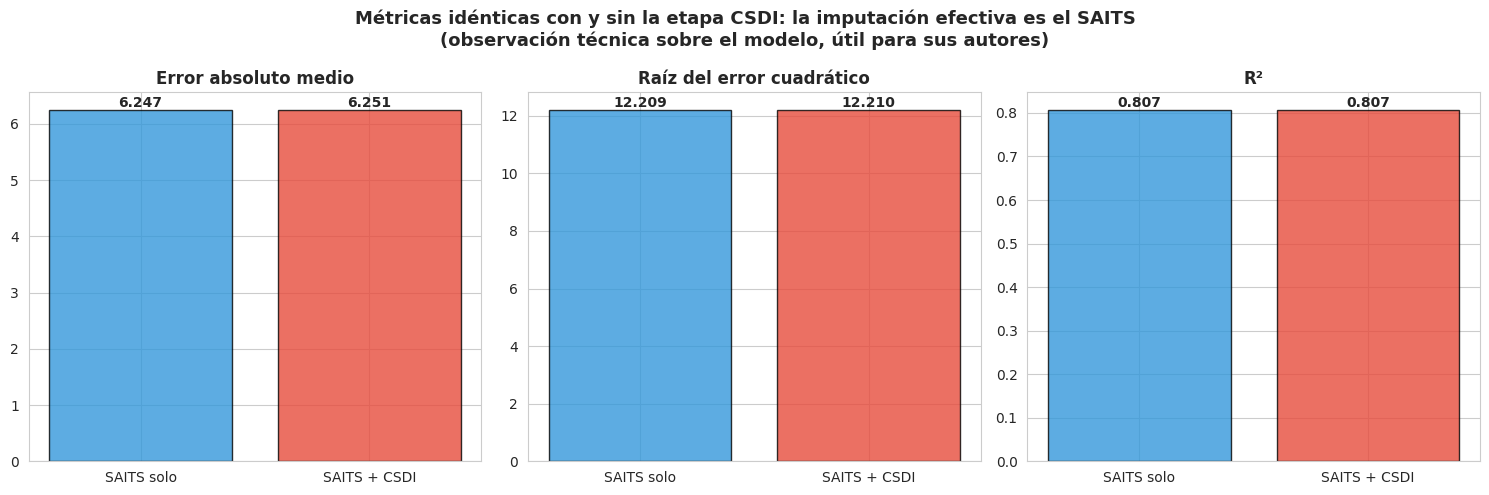

Guardado gráfico en: ../data_processed/mima/01_metricas_auditoria.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metricas = [('MAE', 'Error absoluto medio'), ('RMSE', 'Raíz del error cuadrático'), ('R2', 'R²')]
for ax, (metrica, titulo) in zip(axes, metricas):
    valores = [auditoria['saits'][metrica], auditoria['saits_csdi_ens10'][metrica]]
    bars = ax.bar(['SAITS solo', 'SAITS + CSDI'], valores,
                  color=['#3498db', '#e74c3c'], alpha=0.8, edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(titulo, fontsize=12, fontweight='bold')

fig.suptitle('Métricas idénticas con y sin la etapa CSDI: la imputación efectiva es el SAITS\n(observación técnica sobre el modelo, útil para sus autores)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(mima_dir / '01_metricas_auditoria.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {mima_dir / '01_metricas_auditoria.png'}")

## 3. Consistencia física y química del relleno

Dos verificaciones que no dependen de ninguna métrica de error:
- Física: PM2.5 no puede superar a PM10 (la partícula fina es parte de la gruesa).
- Química: NO2 y O3 deben correlacionar en negativo (el ozono se forma consumiendo NO2).

In [4]:
print("=" * 70)
print("CONSISTENCIA FÍSICA Y QUÍMICA")
print("=" * 70)
print(f"Violaciones físicas (PM2.5 > PM10) en celdas imputadas: {auditoria['saits']['viol_fisica_PM_pct']}%")
print(f"Correlación NO2-O3 en el dataset imputado: {auditoria['saits']['quimica_NO2_O3_corr']}")
print("=> Ambas dentro de lo esperado: la imputación respeta la estructura del fenómeno.")

CONSISTENCIA FÍSICA Y QUÍMICA
Violaciones físicas (PM2.5 > PM10) en celdas imputadas: 0.42%
Correlación NO2-O3 en el dataset imputado: -0.2737
=> Ambas dentro de lo esperado: la imputación respeta la estructura del fenómeno.


## 4. ¿El análisis cambia según la imputación? (híbrida vs MIMA)

La prueba de robustez más importante: todo el pipeline de métodos se corre dos veces.
Aquí se comparan los agregados día-estación de las dos imputaciones.

In [5]:
panel_hibrido = pd.read_csv('../data_processed/panel_pico_hibrido.csv', parse_dates=['date'])
panel_mima = pd.read_csv('../data_processed/panel_pico_MIMA.csv', parse_dates=['date'])

emparejado = panel_hibrido.merge(panel_mima, on=['date', 'estacion'], suffixes=('_h', '_m'))

print("=" * 70)
print("CORRELACIÓN ENTRE AGREGADOS: IMPUTACIÓN HÍBRIDA vs MIMA")
print("=" * 70)
correlaciones = {}
for c in contaminantes:
    correlaciones[c] = emparejado[f'{c}_h'].corr(emparejado[f'{c}_m'])
    print(f"  {c}: r = {correlaciones[c]:.4f}")

pd.Series(correlaciones, name='correlacion').to_csv(mima_dir / 'correlaciones_hibrido_vs_mima.csv')
print(f"\nGuardado en: {mima_dir / 'correlaciones_hibrido_vs_mima.csv'}")

CORRELACIÓN ENTRE AGREGADOS: IMPUTACIÓN HÍBRIDA vs MIMA
  CO: r = 0.9952
  NO2: r = 0.9981
  O3: r = 0.9708
  PM10: r = 0.9988
  PM2.5: r = 0.9882

Guardado en: ../data_processed/mima/correlaciones_hibrido_vs_mima.csv


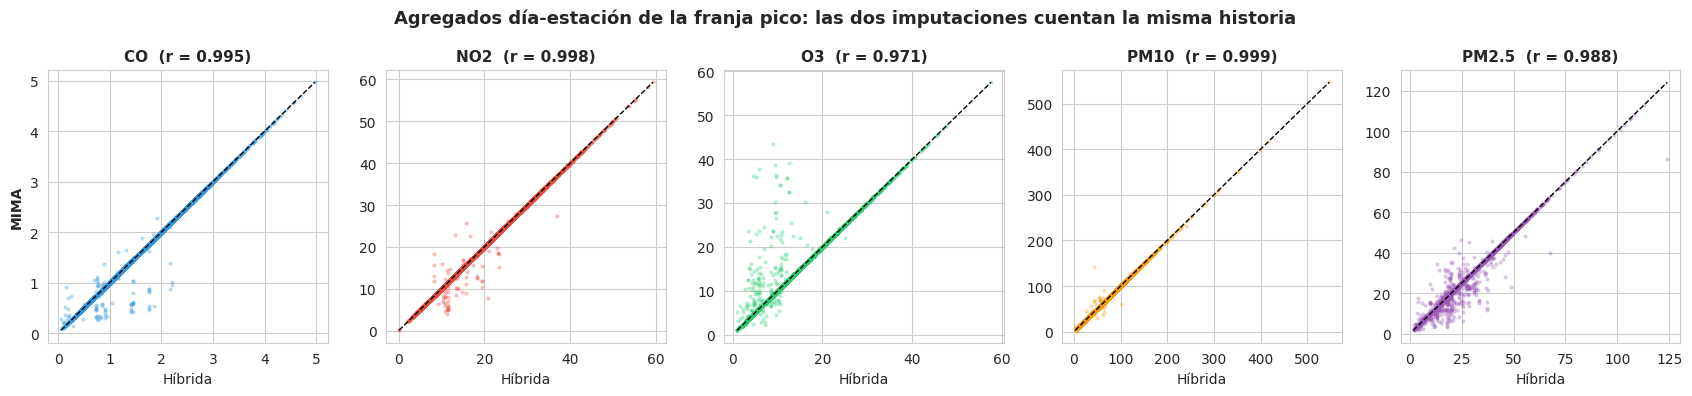

Guardado gráfico en: ../data_processed/mima/02_hibrido_vs_mima_scatter.png

FINALIZADO


In [6]:
fig, axes = plt.subplots(1, 5, figsize=(17, 4))

for ax, c in zip(axes, contaminantes):
    ax.scatter(emparejado[f'{c}_h'], emparejado[f'{c}_m'], s=4, alpha=0.25,
               color=colores_contaminantes[c])
    limites = [emparejado[[f'{c}_h', f'{c}_m']].min().min(), emparejado[[f'{c}_h', f'{c}_m']].max().max()]
    ax.plot(limites, limites, color='black', linewidth=1, linestyle='--')
    ax.set_title(f'{c}  (r = {correlaciones[c]:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Híbrida', fontsize=10)
axes[0].set_ylabel('MIMA', fontsize=10, fontweight='bold')

fig.suptitle('Agregados día-estación de la franja pico: las dos imputaciones cuentan la misma historia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(mima_dir / '02_hibrido_vs_mima_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {mima_dir / '02_hibrido_vs_mima_scatter.png'}")

print('\nFINALIZADO')